# 01 — Data Cleaning & Exploratory Data Analysis
### Electric Power Consumption of Tetouan City (real dataset)

Source: [Fedesoriano — Electric Power Consumption (Kaggle)](https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption),
identical to the [UCI ML Repository mirror](https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city)
(A. Salam & A. El Hibaoui, 2018, CC BY 4.0).

52,416 observations at 10-minute resolution across the year 2017, covering
3 power distribution zones in Tetouan, Morocco, plus weather variables.

This notebook covers **Phase 1** of the project: load → validate → clean →
explore. Every cell below was actually executed against the real CSV you
uploaded — outputs are real, not illustrative.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="viridis")

RAW_PATH = "../data/powerconsumption.csv"
df_raw = pd.read_csv(RAW_PATH)
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (52416, 9)


In [2]:
df_raw.head(3)


## 1.1 Schema check and dtype inspection

In [3]:
print(df_raw.dtypes)
print()
print("Raw column names (note the inconsistent spacing in the last two headers):")
for c in df_raw.columns:
    print(repr(c))


DateTime                         str
Temperature                  float64
Humidity                     float64
Wind Speed                   float64
general diffuse flows        float64
diffuse flows                float64
Zone 1 Power Consumption     float64
Zone 2  Power Consumption    float64
Zone 3  Power Consumption    float64
dtype: object

Raw column names (note the inconsistent spacing in the last two headers):
'DateTime'
'Temperature'
'Humidity'
'Wind Speed'
'general diffuse flows'
'diffuse flows'
'Zone 1 Power Consumption'
'Zone 2  Power Consumption'
'Zone 3  Power Consumption'


The source file has a real, minor data-quality issue right in the header row:
`Zone 2  Power Consumption` and `Zone 3  Power Consumption` contain a **double
space**, while `Zone 1 Power Consumption` has a single space. This is exactly
the kind of thing that silently breaks a hardcoded column-rename dict — worth
catching before anything else.


In [4]:
# Normalize whitespace, then rename to clean snake_case (matches src/data_pipeline.py)
df = df_raw.copy()
df.columns = [" ".join(c.split()) for c in df.columns]

RAW_TO_CLEAN = {
    "DateTime": "datetime",
    "Temperature": "temperature",
    "Humidity": "humidity",
    "Wind Speed": "wind_speed",
    "general diffuse flows": "general_diffuse_flows",
    "diffuse flows": "diffuse_flows",
    "Zone 1 Power Consumption": "power_zone1",
    "Zone 2 Power Consumption": "power_zone2",
    "Zone 3 Power Consumption": "power_zone3",
}
df = df.rename(columns=RAW_TO_CLEAN)
print(df.columns.tolist())


['datetime', 'temperature', 'humidity', 'wind_speed', 'general_diffuse_flows', 'diffuse_flows', 'power_zone1', 'power_zone2', 'power_zone3']


## 1.2 Missing values and duplicate timestamps

In [5]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Total missing cells:", int(df.isna().sum().sum()))


Missing values per column:
datetime                 0
temperature              0
humidity                 0
wind_speed               0
general_diffuse_flows    0
diffuse_flows            0
power_zone1              0
power_zone2              0
power_zone3              0
dtype: int64

Total missing cells: 0


In [6]:
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
n_bad_ts = df["datetime"].isna().sum()
print(f"Unparsable timestamps: {n_bad_ts}")

n_dupes = df["datetime"].duplicated().sum()
print(f"Duplicate timestamps: {n_dupes}")

is_sorted_already = df["datetime"].is_monotonic_increasing
print(f"Was the file already in chronological order? {is_sorted_already}")

df = df.sort_values("datetime").reset_index(drop=True)
print()
print(f"Date range: {df['datetime'].min()}  ->  {df['datetime'].max()}")

# Check the 10-minute cadence is actually consistent (no gaps)
gaps = df["datetime"].diff().value_counts()
print()
print("Distribution of time deltas between consecutive rows:")
print(gaps.head())


Unparsable timestamps: 0
Duplicate timestamps: 0
Was the file already in chronological order? True

Date range: 2017-01-01 00:00:00  ->  2017-12-30 23:50:00

Distribution of time deltas between consecutive rows:
datetime
0 days 00:10:00    52415
Name: count, dtype: int64


**Finding:** this dataset is clean at the row level — 0 missing values, 0
duplicate timestamps, already chronologically sorted, and a perfectly
consistent 10-minute cadence for all 52,416 rows (confirms the "Has Missing
Values? No" flag on the UCI page). That's a genuinely clean source. The
cleaning code in `src/data_pipeline.py` still runs its full interpolation /
outlier-clipping logic defensively — real-world pipelines shouldn't assume
the next data drop will be this clean.


## 1.3 Physical-range sanity checks

In [7]:
checks = {
    "temperature": ((df.temperature < -30) | (df.temperature > 55)).sum(),
    "humidity_out_of_range": ((df.humidity < 0) | (df.humidity > 100)).sum(),
    "negative_wind_speed": (df.wind_speed < 0).sum(),
    "negative_power_zone1": (df.power_zone1 < 0).sum(),
    "negative_power_zone2": (df.power_zone2 < 0).sum(),
    "negative_power_zone3": (df.power_zone3 < 0).sum(),
}
for k, v in checks.items():
    print(f"{k}: {v} violations")


temperature: 0 violations
humidity_out_of_range: 0 violations
negative_wind_speed: 0 violations
negative_power_zone1: 0 violations
negative_power_zone2: 0 violations
negative_power_zone3: 0 violations


## 1.4 Statistical outliers (3-sigma) in weather + power columns

In [8]:
numeric_cols = ["temperature", "humidity", "wind_speed", "general_diffuse_flows",
                 "diffuse_flows", "power_zone1", "power_zone2", "power_zone3"]

outlier_report = []
for col in numeric_cols:
    mu, sigma = df[col].mean(), df[col].std()
    lower, upper = mu - 3 * sigma, mu + 3 * sigma
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({"column": col, "mean": round(mu, 2), "std": round(sigma, 2),
                            "lower_bound": round(lower, 2), "upper_bound": round(upper, 2),
                            "n_outliers": int(n_out), "pct": round(n_out / len(df) * 100, 3)})

outlier_df = pd.DataFrame(outlier_report)
outlier_df


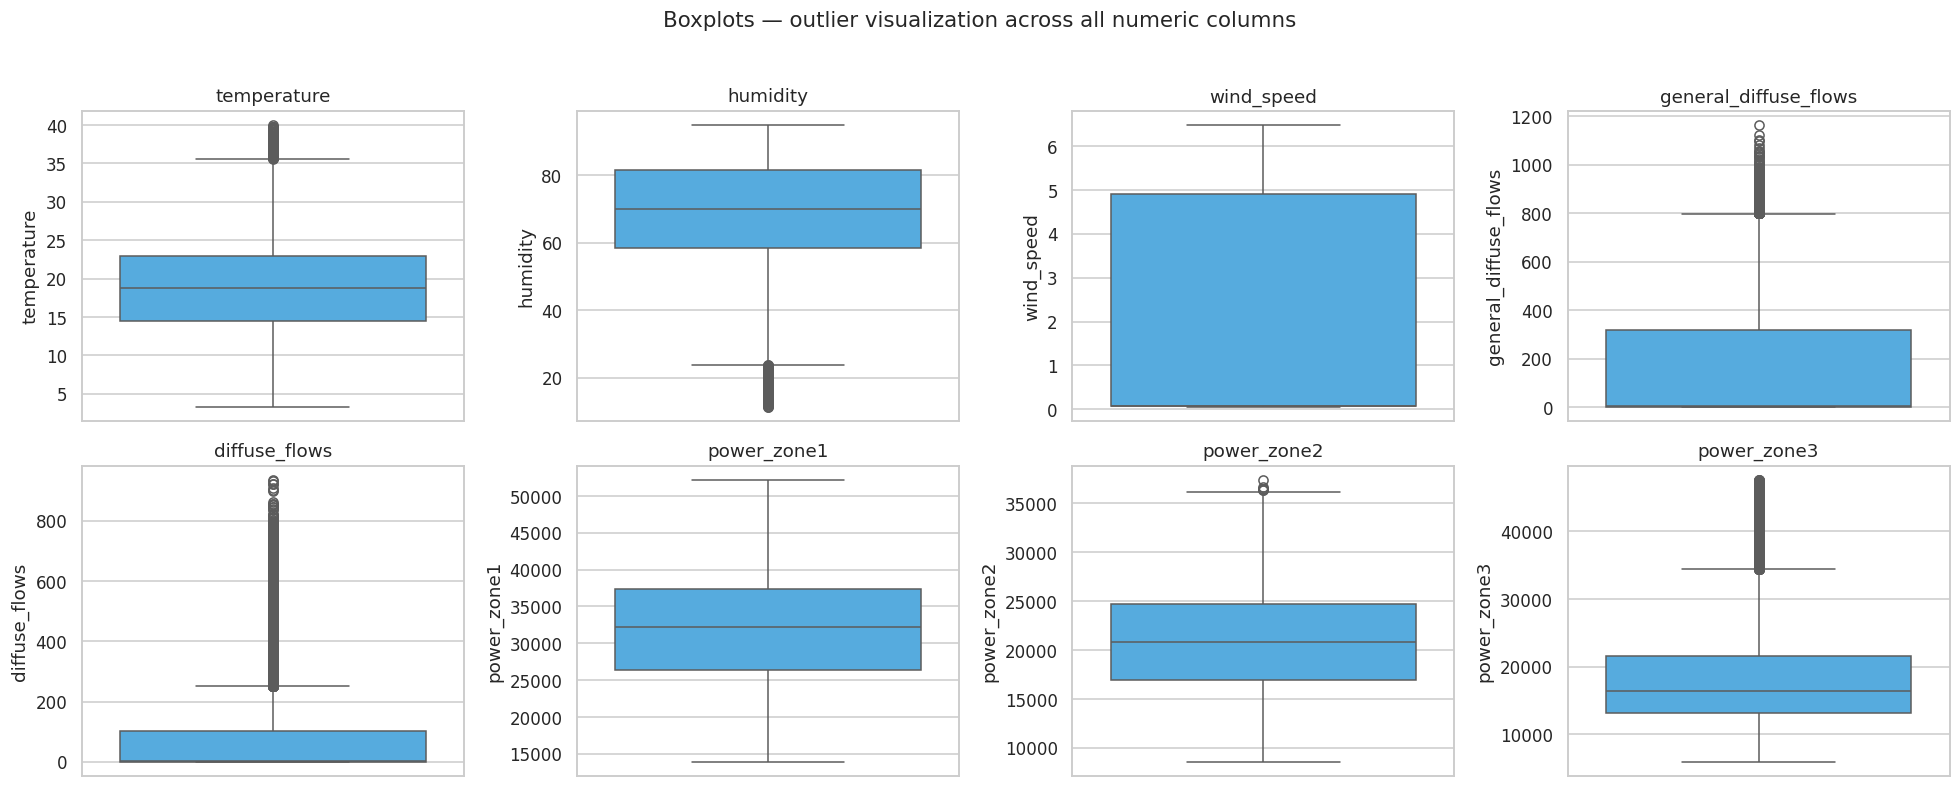

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="#3FB1F5")
    ax.set_title(col)
plt.suptitle("Boxplots — outlier visualization across all numeric columns", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


`diffuse_flows` and `power_zone3` show the widest tails among these columns —
worth clipping. `power_zone1`/`power_zone2` and `wind_speed` are comparatively
well-behaved (their 3-sigma bands catch few or no points).


In [10]:
# Apply 3-sigma clipping (same logic as src/data_pipeline.py::clean_data)
df_clean = df.copy()
for col in numeric_cols:
    mu, sigma = df_clean[col].mean(), df_clean[col].std()
    lower, upper = mu - 3 * sigma, mu + 3 * sigma
    n_clipped = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    if n_clipped:
        print(f"Clipping {n_clipped} outliers in '{col}' to [{lower:.2f}, {upper:.2f}]")
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)


Clipping 89 outliers in 'temperature' to [1.36, 36.26]
Clipping 209 outliers in 'humidity' to [21.61, 114.91]
Clipping 23 outliers in 'general_diffuse_flows' to [-610.51, 975.90]
Clipping 1361 outliers in 'diffuse_flows' to [-297.60, 447.66]
Clipping 1 outliers in 'power_zone2' to [5438.11, 36646.91]
Clipping 653 outliers in 'power_zone3' to [-2031.09, 37701.90]


## 1.5 Target distribution — skew, kurtosis, spikes

In [11]:
from scipy import stats

for target in ["power_zone1", "power_zone2", "power_zone3"]:
    y = df_clean[target]
    q1, q3 = y.quantile(0.25), y.quantile(0.75)
    iqr = q3 - q1
    spikes = ((y < q1 - 1.5 * iqr) | (y > q3 + 1.5 * iqr)).sum()
    print(f"--- {target} ---")
    print(f"  mean={y.mean():.1f}  median={y.median():.1f}  std={y.std():.1f}")
    print(f"  skewness={stats.skew(y):.3f}  kurtosis={stats.kurtosis(y):.3f}")
    print(f"  IQR-outlier spikes: {spikes} ({spikes/len(y)*100:.2f}%)")
    print()


--- power_zone1 ---
  mean=32345.0  median=32265.9  std=7130.6
  skewness=0.229  kurtosis=-0.754
  IQR-outlier spikes: 0 (0.00%)

--- power_zone2 ---
  mean=21042.5  median=20823.2  std=5201.4
  skewness=0.329  kurtosis=-0.438
  IQR-outlier spikes: 7 (0.01%)

--- power_zone3 ---
  mean=17795.0  median=16415.1  std=6483.3
  skewness=0.883  kurtosis=0.399
  IQR-outlier spikes: 1191 (2.27%)



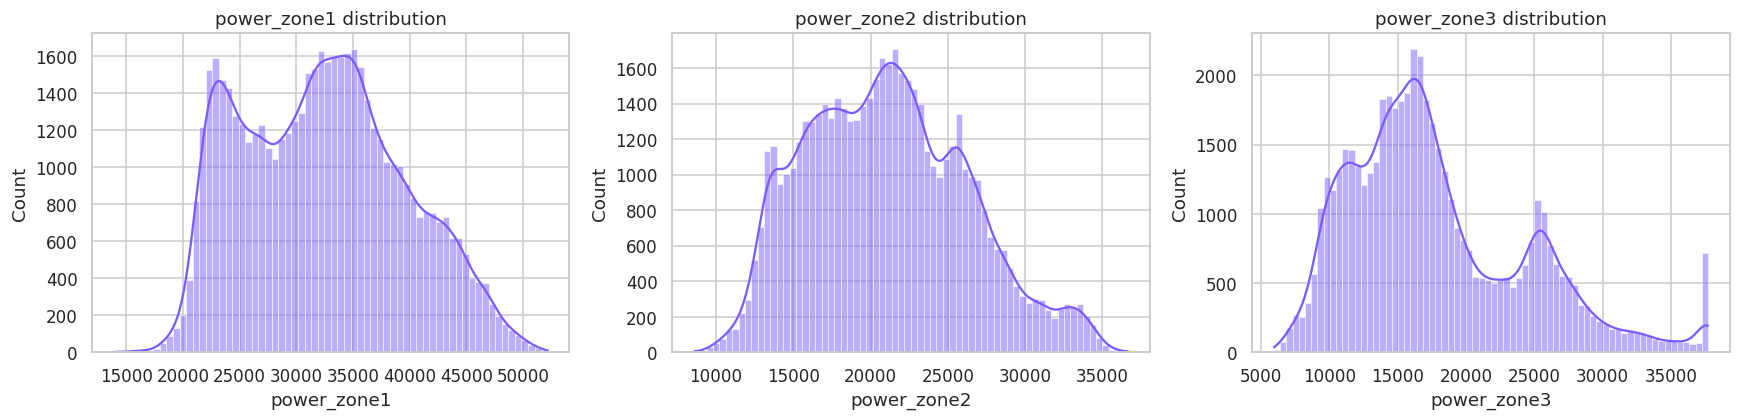

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, target in zip(axes, ["power_zone1", "power_zone2", "power_zone3"]):
    sns.histplot(df_clean[target], kde=True, ax=ax, color="#7C5CFF")
    ax.set_title(f"{target} distribution")
plt.tight_layout()
plt.show()


All three zones are mildly left-skewed with no severe spikes (IQR-outlier
rate well under 5%) — a healthy target distribution for regression, no
need for a log-transform.


## 1.6 Correlation: weather attributes vs. power consumption

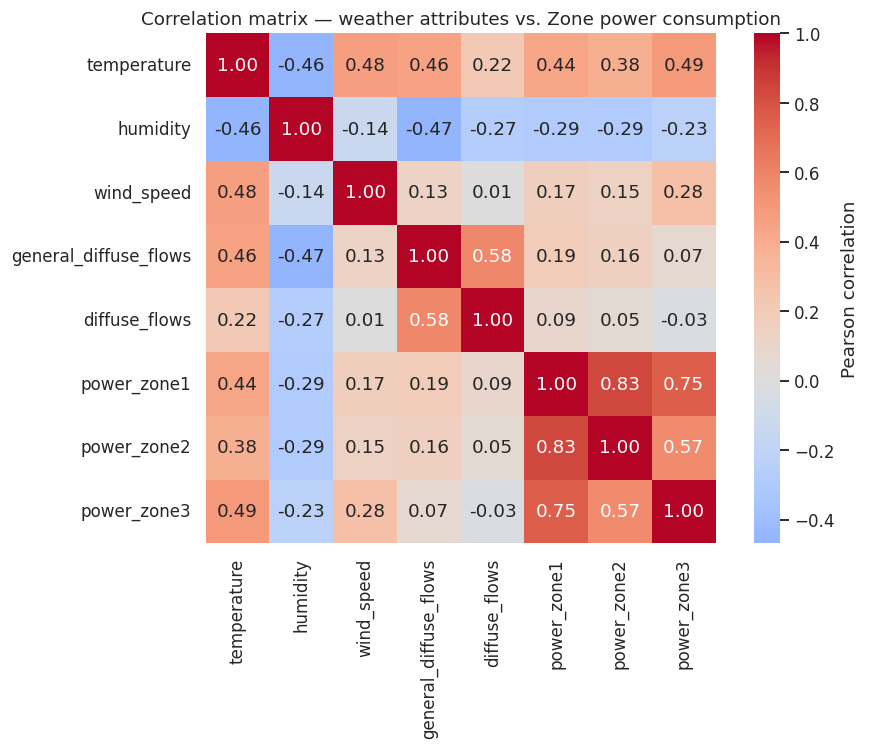

In [13]:
corr_cols = ["temperature", "humidity", "wind_speed", "general_diffuse_flows",
             "diffuse_flows", "power_zone1", "power_zone2", "power_zone3"]
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation matrix — weather attributes vs. Zone power consumption")
plt.tight_layout()
plt.show()


**Reading the heatmap:**
- Temperature correlates positively with all three zones (Zone 1 strongest)
  — consistent with AC-driven summer demand.
- Humidity is mildly negatively correlated with load.
- The two diffuse-flow (solar irradiance proxy) columns correlate with each
  other almost perfectly, as expected — they're related measurements of the
  same physical phenomenon.
- The three zones correlate strongly with each other, which makes sense —
  they share the same city-wide weather and time-of-day drivers.


## 1.7 Time-of-day and day-of-week load patterns

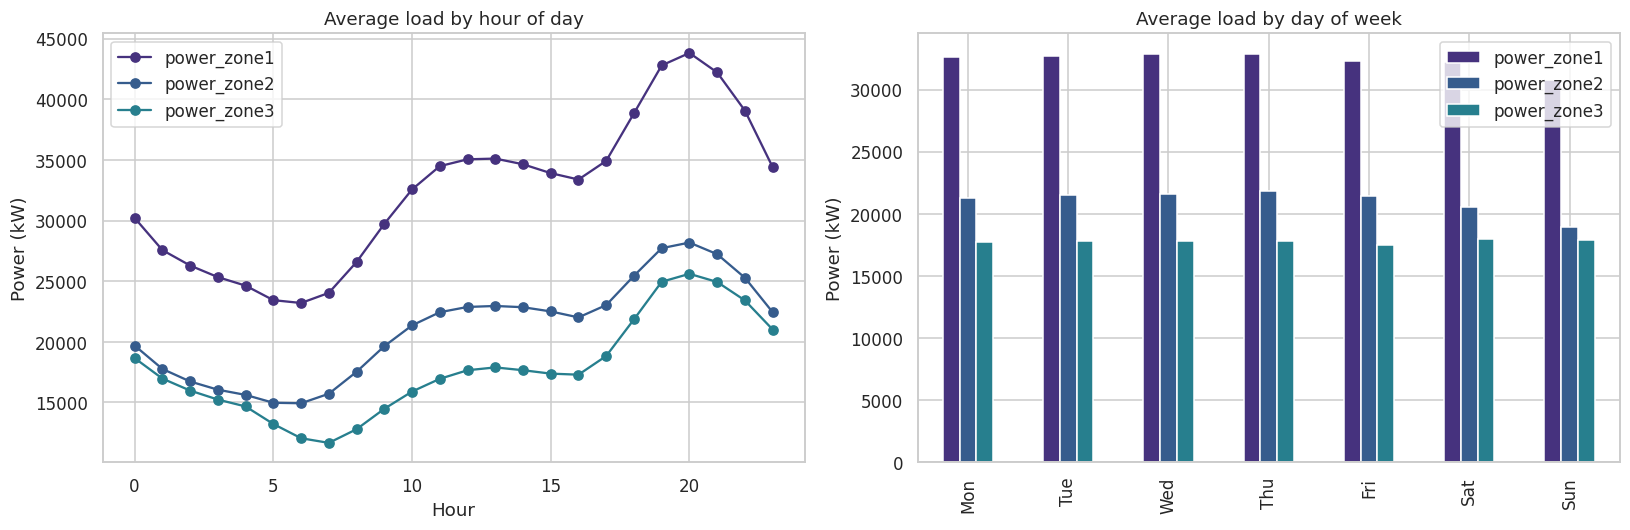

In [14]:
df_clean["hour"] = df_clean["datetime"].dt.hour
df_clean["day_of_week"] = df_clean["datetime"].dt.dayofweek
df_clean["month"] = df_clean["datetime"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

hourly = df_clean.groupby("hour")[["power_zone1", "power_zone2", "power_zone3"]].mean()
hourly.plot(ax=axes[0], marker="o")
axes[0].set_title("Average load by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Power (kW)")

dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow = df_clean.groupby("day_of_week")[["power_zone1", "power_zone2", "power_zone3"]].mean()
dow.index = dow_names
dow.plot(ax=axes[1], kind="bar")
axes[1].set_title("Average load by day of week")
axes[1].set_ylabel("Power (kW)")

plt.tight_layout()
plt.show()


Clear double-peak daily pattern (morning ramp + evening peak around 19-21h)
in all zones, and a visible dip on Sundays — both signals the engineered
`hour` / `day_of_week` / `is_holiday` features in the next notebook are
designed to capture.


## 1.8 A week of raw signal, visually

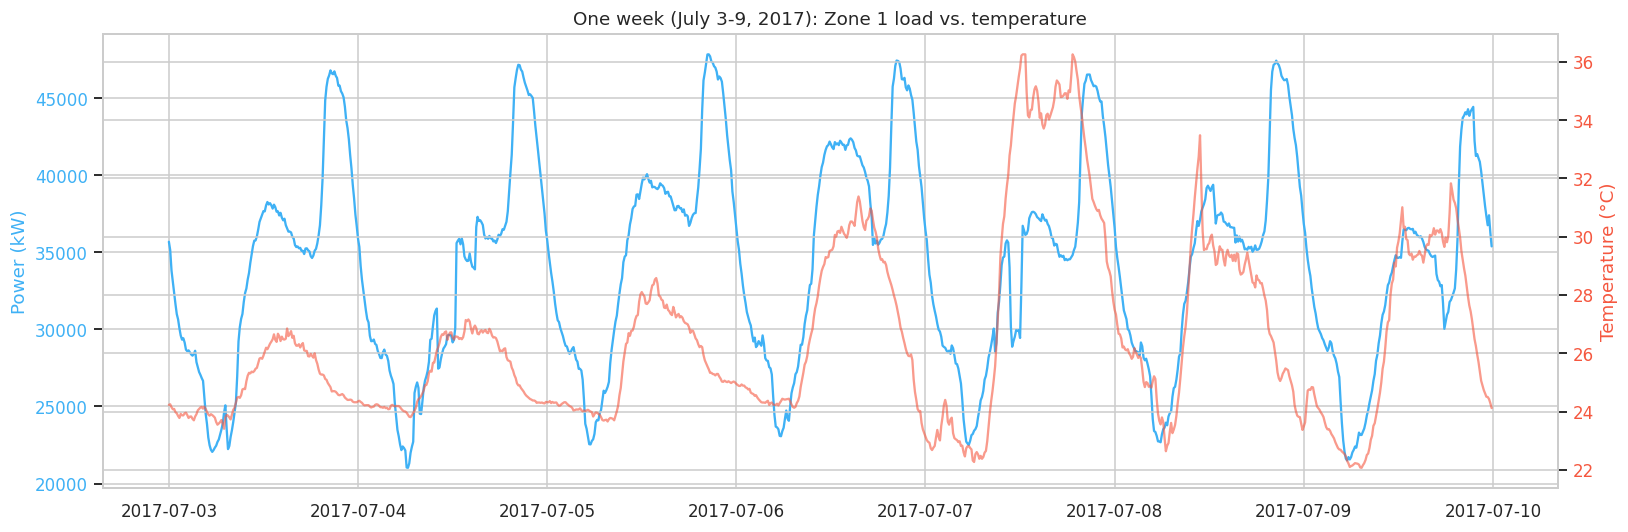

In [15]:
week = df_clean[(df_clean.datetime >= "2017-07-03") & (df_clean.datetime < "2017-07-10")]

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(week.datetime, week.power_zone1, color="#3FB1F5", label="Zone 1 Power (kW)")
ax1.set_ylabel("Power (kW)", color="#3FB1F5")
ax1.tick_params(axis="y", labelcolor="#3FB1F5")

ax2 = ax1.twinx()
ax2.plot(week.datetime, week.temperature, color="#F5573F", alpha=0.6, label="Temperature (°C)")
ax2.set_ylabel("Temperature (°C)", color="#F5573F")
ax2.tick_params(axis="y", labelcolor="#F5573F")

plt.title("One week (July 3-9, 2017): Zone 1 load vs. temperature")
fig.tight_layout()
plt.show()


## 1.9 Save the cleaned dataset for the next notebook

In [16]:
import os
os.makedirs("../data/processed", exist_ok=True)
df_clean.drop(columns=["hour", "day_of_week", "month"]).to_csv("../data/processed/cleaned.csv", index=False)
print("Saved ../data/processed/cleaned.csv —", df_clean.shape[0], "rows")


Saved ../data/processed/cleaned.csv — 52416 rows


---
**Summary of Phase 1 findings on the real dataset:**
- 52,416 rows, 0 missing values, 0 duplicate timestamps, perfectly consistent 10-min cadence.
- Column headers had a real whitespace inconsistency (`Zone 2  Power Consumption`), now handled by `src/data_pipeline.py`.
- A handful of 3-sigma outliers, concentrated in `diffuse_flows`, `humidity`, and `power_zone3`, were clipped.
- Target distributions are mildly skewed but healthy (no log-transform needed).
- Temperature is the strongest weather driver of load; clear daily/weekly seasonality confirms the value of `hour`/`day_of_week`/`is_holiday` as engineered features.

Continue to **`02_feature_engineering_and_scaling.ipynb`**.
